In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Garantir que os resultados sejam reproduzíveis
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Carregar o dataset Pima Indians Diabetes
print("Carregando dataset de diabetes...")
diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
X = diabetes.data.values.astype(float)
# Converter classes: 'tested_negative' -> 0, 'tested_positive' -> 1
y = (diabetes.target.values == 'tested_positive').astype(int)

# Divisão: 70% Treino, 15% Validação, 15% Teste
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Normalização (Essencial para redes neurais)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Dataset carregado! Total de colunas (features): {X.shape[1]}")
print(f"Amostras - Treino: {len(X_train)}, Validação: {len(X_val)}, Teste: {len(X_test)}")

Carregando dataset de diabetes...
Dataset carregado! Total de colunas (features): 8
Amostras - Treino: 537, Validação: 115, Teste: 116


In [3]:
# Conversão para tensores PyTorch (Padronizando nomes)
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train) # Agora o nome está correto: y_train_tensor

X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Recriando os DataLoaders com os novos nomes
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

print("Tensores criados e DataLoaders prontos!")

Tensores criados e DataLoaders prontos!


In [4]:
class DiabetesMLP_Ultra(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DiabetesMLP_Ultra, self).__init__()
        
        # Camada 1: Entrada + Estabilização
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim) # Estabiliza os dados internamente
        
        # Camada 2: Processamento Intermediário
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        
        # Ativações e Dropout
        self.leaky_relu = nn.LeakyReLU(0.1) # Evita que neurônios "morram"
        self.dropout = nn.Dropout(p=0.3)    # Regularização
        
        # Camada de Saída
        self.output_layer = nn.Linear(hidden_dim // 2, output_dim)
        
    def forward(self, x):
        # Fluxo: Camada -> Batch Norm -> Ativação -> Dropout
        x = self.leaky_relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        
        x = self.leaky_relu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        
        x = self.output_layer(x)
        return x

In [5]:
def train_model_ultra(hidden_dim, lr, num_epochs, train_loader, val_loader, y_train_tensor):
    model = DiabetesMLP_Ultra(input_dim=8, hidden_dim=hidden_dim, output_dim=2)
    
    # 1. Pesos de Classe: Dá mais importância para a classe "Diabético" (reduz Falsos Negativos)
    counts = torch.bincount(y_train_tensor)
    # Peso inverso à frequência: quanto menos exemplos da classe, mais peso ela ganha
    weights = 1.0 / counts.float()
    weights = weights / weights.sum()
    criterion = nn.CrossEntropyLoss(weight=weights)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # 2. Scheduler: Reduz o LR se a perda parar de cair (ajuste fino final)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
    
    t_losses, v_losses = [], []
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        t_losses.append(avg_train_loss)
        
        # Validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                v_l = criterion(model(X_b), y_b).item()
                val_loss += v_l
        
        avg_val_loss = val_loss / len(val_loader)
        v_losses.append(avg_val_loss)
        
        # Informa o Scheduler sobre a performance
        scheduler.step(avg_val_loss)

    return model, t_losses, v_losses

In [6]:
def evaluate_model(model, loader):
    model.eval() # Desativa o Dropout para garantir previsões consistentes
    y_p, y_t = [], []
    
    with torch.no_grad(): # Desativa o cálculo de gradientes (economiza memória e tempo)
        for X_b, y_b in loader:
            outputs = model(X_b)
            _, pred = torch.max(outputs, 1) # Pega o índice da classe com maior probabilidade
            y_p.extend(pred.numpy())
            y_t.extend(y_b.numpy())
    
    # Calcula a média de acertos
    acc = (np.array(y_p) == np.array(y_t)).mean() * 100
    return acc, y_t, y_p


Treinando Arquitetura Ultra: Ocultas=32, LR=0.001


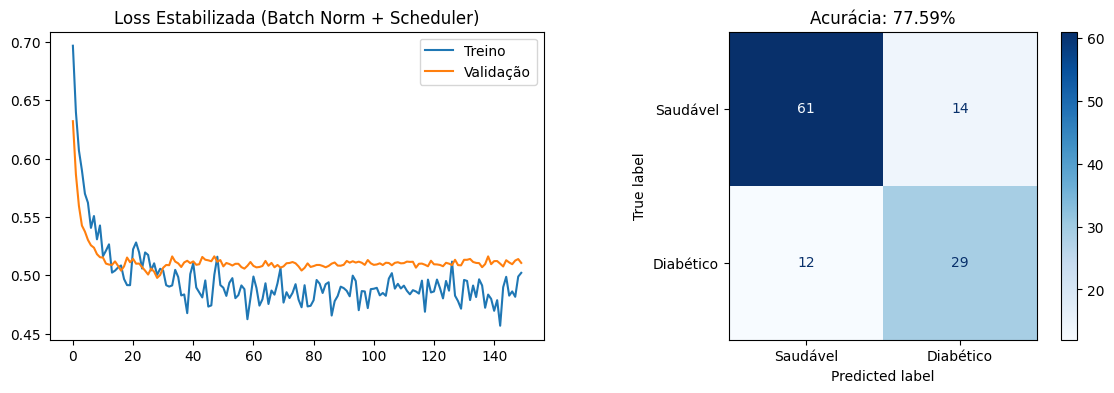


Treinando Arquitetura Ultra: Ocultas=64, LR=0.0005


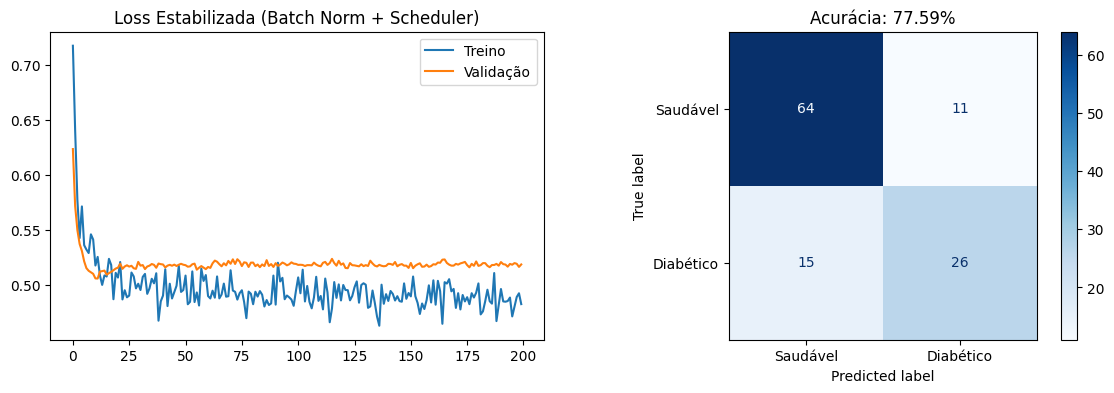


=== Relatório Final Ultra ===


,Config,Acurácia
0,"H:32, LR:0.001",77.59%
1,"H:64, LR:0.0005",77.59%


In [7]:
# Configurações para teste
configs = [
    {'hidden': 32, 'lr': 0.001, 'epochs': 150},
    {'hidden': 64, 'lr': 0.0005, 'epochs': 200} # Testando uma rede um pouco maior
]

final_results = []

for c in configs:
    print(f"\nTreinando Arquitetura Ultra: Ocultas={c['hidden']}, LR={c['lr']}")
    
    # AGORA PASSANDO O 'y_train_tensor' QUE ESTAVA FALTANDO:
    model, t_loss, v_loss = train_model_ultra(
        c['hidden'], 
        c['lr'], 
        c['epochs'], 
        train_loader, 
        val_loader, 
        y_train_tensor # O argumento que causou o erro
    )
    
    acc, y_true, y_pred = evaluate_model(model, test_loader)
    
    final_results.append({
        'Config': f"H:{c['hidden']}, LR:{c['lr']}", 
        'Acurácia': f"{acc:.2f}%"
    })
    
    # Gráficos de performance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(t_loss, label='Treino')
    ax1.plot(v_loss, label='Validação')
    ax1.set_title(f"Loss Estabilizada (Batch Norm + Scheduler)")
    ax1.legend()
    
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Saudável', 'Diabético']).plot(ax=ax2, cmap='Blues')
    ax2.set_title(f"Acurácia: {acc:.2f}%")
    plt.show()

print("\n=== Relatório Final Ultra ===")
display(pd.DataFrame(final_results))